# 🧬 Laboratorio 1 — Manejo de Secuencias Biológicas

**Curso:** Bioinformática
**Repositorio:** `bio-notebooks`  
**Herramientas:** Python 3, matplotlib

---

## Competencias
- Comprender la estructura de archivos biológicos
- Manipular cadenas de ADN/ARN usando estructuras de datos eficientes

## Contenido de este cuaderno
1. Marco teórico formato FASTA y contenido GC
2. Implementación de clases: `FastaRecord`, `FastaReader`, `SequenceStats`
3. Análisis de tres secuencias reales de NCBI
4. Visualización con matplotlib
5. Preguntas de reflexión


## 0. Dependencias

Instalación de librerías necesarias , solo se ejcuta una vez:


In [1]:
# Ejecutar solo si no están instaladas
!pip install matplotlib biopython


   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------- ----------------- 1.6/2.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 9.4 MB/s eta 0:00:00


## 1. Marco Teórico

### 1.1 Formato FASTA

El formato FASTA es el estándar en bioinformática para representar secuencias biológicas (ADN, ARN, proteínas). Es texto plano con dos partes por registro:

```
>NM_000518.5 Homo sapiens hemoglobin subunit beta (HBB), mRNA
ATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAAC
GTGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCA
...
```

| Parte | Descripción |
|---|---|
| `>` | Indica inicio de un nuevo registro |
| `NM_000518.5` | Identificador único (primer token) |
| `Homo sapiens...` | Descripción (resto del encabezado) |
| Líneas siguientes | Secuencia biológica (puede estar en múltiples líneas) |

Un archivo FASTA puede contener **una o múltiples secuencias**. Las secuencias multi-línea representan una cadena continua y deben concatenarse al leer.

### 1.2 Proporción de Contenido GC

El **GC%** indica la proporción de guanina (G) y citosina (C) en la secuencia.  
Es importante porque los pares G-C forman **3 puentes de hidrógeno** (más estables que A-T con 2).

$$GC\% = \frac{G + C}{A + T + G + C} \times 100$$

### 1.3 Secuencias utilizadas

| Tamaño | Organismo | Accession | Longitud | GC% |
|---|---|---|---|---|
| Pequeña | *Homo sapiens* HBB | NM_000518.5 | 628 bp | 51.27% |
| Mediana | *H. sapiens* mitocondria | NC_012920.1 | 16,569 bp | 44.36% |
| Grande | *E. coli* K-12 | U00096.3 | 4,641,652 bp | 50.79% |


## 2. Implementación

### 2.1 `FastaRecord` Modelo de datos (Ejercicio 3)

Representa un único registro FASTA. Usamos `@dataclass` para que Python genere automáticamente `__init__`, `__repr__`, etc.


In [3]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Iterator
import os
import time
import statistics

@dataclass
class FastaRecord:
    """
    Representa un único registro FASTA.

    Atributos
    ---------
    id          : identificador (primer token del encabezado)
    description : resto del encabezado (sin el '>')
    sequence    : cadena de nucleótidos continua
    """
    id:          str
    description: str
    sequence:    str

    @property
    def length(self) -> int:
        """Longitud de la secuencia en pares de bases (bp)."""
        return len(self.sequence)

    @property
    def gc_content(self) -> float:
        """
        Calcula GC% usando la fórmula del marco teórico:
            GC% = (G + C) / (A + T + G + C) * 100
        """
        seq   = self.sequence.upper()
        g     = seq.count('G')
        c     = seq.count('C')
        a     = seq.count('A')
        t     = seq.count('T')
        total = a + t + g + c
        if total == 0:
            return 0.0
        return (g + c) / total * 100.0

    def count_base(self, base: str) -> int:
        """Cuenta ocurrencias de una base (A/T/G/C)."""
        return self.sequence.upper().count(base.upper())

    def __repr__(self) -> str:
        return (f"FastaRecord(id={self.id!r}, "
                f"length={self.length:,} bp, gc={self.gc_content:.2f}%)")

# Prueba de funcoinameitno
rec = FastaRecord("TEST", "secuencia de prueba", "AATTGGCC")
print(f"ID      : {rec.id}")
print(f"Longitud: {rec.length} bp")
print(f"GC%     : {rec.gc_content:.2f}%  (esperado: 50.00%)")
print(f"Repr    : {rec}")


ID      : TEST
Longitud: 8 bp
GC%     : 50.00%  (esperado: 50.00%)
Repr    : FastaRecord(id='TEST', length=8 bp, gc=50.00%)


### 2.2 `FastaReader` Lectura de archivos FASTA (Ejercicio 2)

Separa la responsabilidad de I/O del modelo de datos.  
La función `parse()` recorre el archivo línea a línea: cuando encuentra `>` guarda el registro anterior y empieza uno nuevo.


In [6]:
class FastaReader:
    """
    Lee archivos en formato FASTA y los convierte a FastaRecord.

    Uso
    ---
    reader  = FastaReader("genome.fasta")
    records = reader.parse()         # carga todo en memoria
    for rec in FastaReader("big.fasta"):  # streaming
        process(rec)
    """

    def __init__(self, filepath: str) -> None:
        self.filepath = filepath

    def parse(self) -> list[FastaRecord]:
        """Lee el archivo y retorna lista de FastaRecord."""
        if not os.path.exists(self.filepath):
            raise FileNotFoundError(f"No se encontró: {self.filepath}")

        records: list[FastaRecord] = []
        current_id:   str | None   = None
        current_desc: str          = ""
        buffer:       list[str]    = []

        def _flush():
            if current_id is not None:
                records.append(FastaRecord(
                    id=current_id,
                    description=current_desc,
                    sequence=''.join(buffer),
                ))

        with open(self.filepath, 'r') as fh:
            for line in fh:
                line = line.rstrip('\n').rstrip('\r')
                if not line:
                    continue
                if line.startswith('>'):
                    _flush()
                    parts        = line[1:].split(None, 1)
                    current_id   = parts[0]
                    current_desc = parts[1] if len(parts) > 1 else ""
                    buffer       = []
                else:
                    buffer.append(line.upper())
        _flush()
        return records

    def __iter__(self) -> Iterator[FastaRecord]:
        """Streaming: cede un registro a la vez , sera util cuando usmeos archivos grandes."""
        current_id:   str | None = None
        current_desc: str        = ""
        buffer:       list[str]  = []

        with open(self.filepath, 'r') as fh:
            for line in fh:
                line = line.rstrip('\n').rstrip('\r')
                if not line:
                    continue
                if line.startswith('>'):
                    if current_id is not None:
                        yield FastaRecord(current_id, current_desc, ''.join(buffer))
                    parts        = line[1:].split(None, 1)
                    current_id   = parts[0]
                    current_desc = parts[1] if len(parts) > 1 else ""
                    buffer       = []
                else:
                    buffer.append(line.upper())
            if current_id is not None:
                yield FastaRecord(current_id, current_desc, ''.join(buffer))

print("FastaReader definido correctamente")


FastaReader definido correctamente


### 2.3 `SequenceStats` Estadísticas

Calcula longitud mínima, máxima, promedio y GC% sobre una colección de registros.  
Todos los métodos son **estáticos** no necesita estado propio.


In [7]:
@dataclass
class StatsResult:
    """Agrupa los resultados estadísticos de una colección."""
    count:     int
    min_len:   int
    max_len:   int
    mean_len:  float
    mean_gc:   float
    lengths:   list[int]   = field(default_factory=list)
    gc_values: list[float] = field(default_factory=list)


class SequenceStats:
    """Calcula estadísticas sobre una colección de FastaRecord."""

    @staticmethod
    def compute(records: list[FastaRecord]) -> StatsResult:
        """Estadísticas de longitud y GC sobre toda la colección."""
        if not records:
            return StatsResult(0, 0, 0, 0.0, 0.0)
        lengths   = [r.length     for r in records]
        gc_values = [r.gc_content for r in records]
        return StatsResult(
            count    = len(records),
            min_len  = min(lengths),
            max_len  = max(lengths),
            mean_len = statistics.mean(lengths),
            mean_gc  = statistics.mean(gc_values),
            lengths  = lengths,
            gc_values= gc_values,
        )

    @staticmethod
    def print_report(label: str, records: list[FastaRecord],
                     stats: StatsResult, elapsed_ms: float) -> None:
        SEP = "=" * 65
        print(f"\n{SEP}")
        print(f"  {label}")
        print(f"  Secuencias : {stats.count} | Tiempo: {elapsed_ms:.2f} ms")
        print(SEP)
        print(f"  Mínima   : {stats.min_len:>12,} bp")
        print(f"  Máxima   : {stats.max_len:>12,} bp")
        print(f"  Promedio : {stats.mean_len:>12,.2f} bp")
        print(f"  GC% prom : {stats.mean_gc:>11.2f} %")
        print(f"\n  {'ID':<26} {'Longitud (bp)':>13} {'GC%':>9}")
        print("  " + "-" * 50)
        for rec in records[:10]:
            sid = (rec.id[:23] + '..') if len(rec.id) > 25 else rec.id
            print(f"  {sid:<26} {rec.length:>13,} {rec.gc_content:>8.2f}%")
        if len(records) > 10:
            print(f"  ... ({len(records)-10} más)")
        print(SEP)

print("SequenceStats definido correctamente")


SequenceStats definido correctamente


## 3. Análisis de Secuencias Reales

Procesamos los tres archivos FASTA descargados de NCBI.  
Ajusta la variable `DATA_DIR` si tus archivos están en otra ubicación.


In [9]:
# Ajusta esta ruta según la ubicación de tus archivos
DATA_DIR = "data"   # relativo al notebook

ARCHIVOS = [
    ("hbb_small.fasta",   "HBB Humana (pequeña)  NM_000518.5"),
    ("mito_medium.fasta", "Mitocondria (mediana)  NC_012920.1"),
    ("ecoli_large.fasta", "E. coli K-12 (grande)  U00096.3"),
]

resultados = []   # guardamos para visualizar después

for fname, label in ARCHIVOS:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"⚠️  No encontrado: {path}")
        continue

    t0      = time.perf_counter()
    records = FastaReader(path).parse()
    elapsed = (time.perf_counter() - t0) * 1000

    stats = SequenceStats.compute(records)
    SequenceStats.print_report(label, records, stats, elapsed)
    resultados.append((label, records, stats))



  HBB Humana (pequeña)  NM_000518.5
  Secuencias : 1 | Tiempo: 0.58 ms
  Mínima   :          628 bp
  Máxima   :          628 bp
  Promedio :       628.00 bp
  GC% prom :       51.27 %

  ID                         Longitud (bp)       GC%
  --------------------------------------------------
  NM_000518.5                          628    51.27%

  Mitocondria (mediana)  NC_012920.1
  Secuencias : 1 | Tiempo: 0.72 ms
  Mínima   :       16,569 bp
  Máxima   :       16,569 bp
  Promedio :    16,569.00 bp
  GC% prom :       44.36 %

  ID                         Longitud (bp)       GC%
  --------------------------------------------------
  NC_012920.1                       16,569    44.36%

  E. coli K-12 (grande)  U00096.3
  Secuencias : 1 | Tiempo: 31.36 ms
  Mínima   :    4,641,652 bp
  Máxima   :    4,641,652 bp
  Promedio : 4,641,652.00 bp
  GC% prom :       50.79 %

  ID                         Longitud (bp)       GC%
  --------------------------------------------------
  U00096.3     

## 4. Visualización

Para cada archivo generamos tres paneles:
- **Izquierda:** GC% por secuencia (rojo < 40%, azul 40-60%, verde > 60%)
- **Centro:** Histograma de longitudes con media, mínimo y máximo
- **Derecha:** Composición nucleotídica total (A/T/G/C)


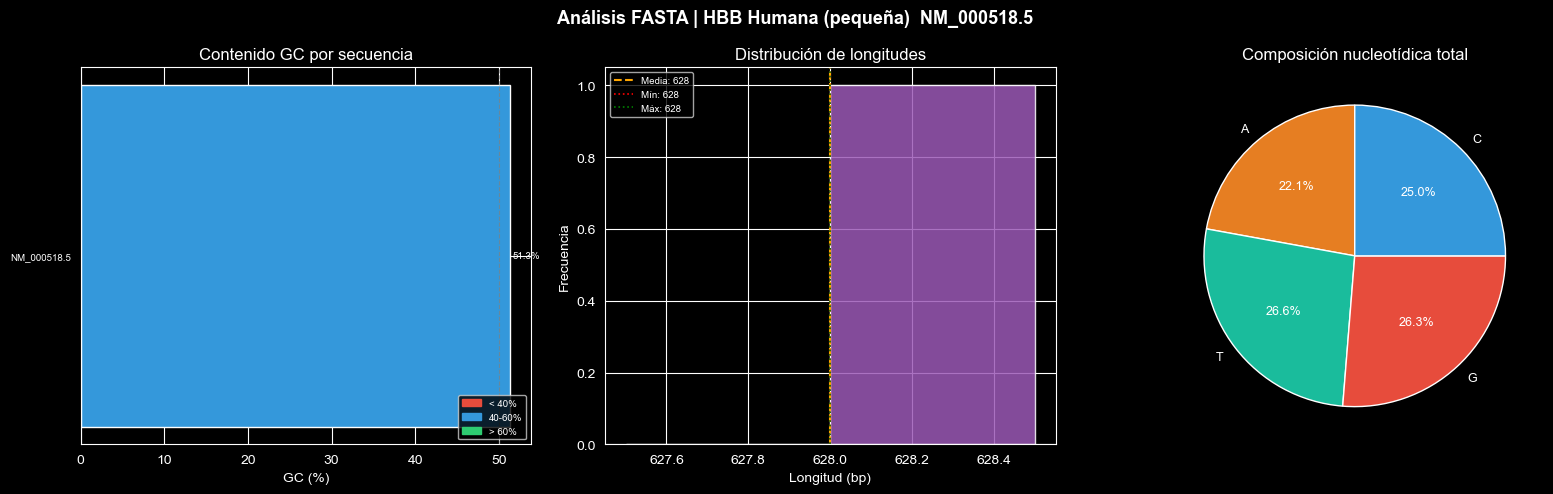

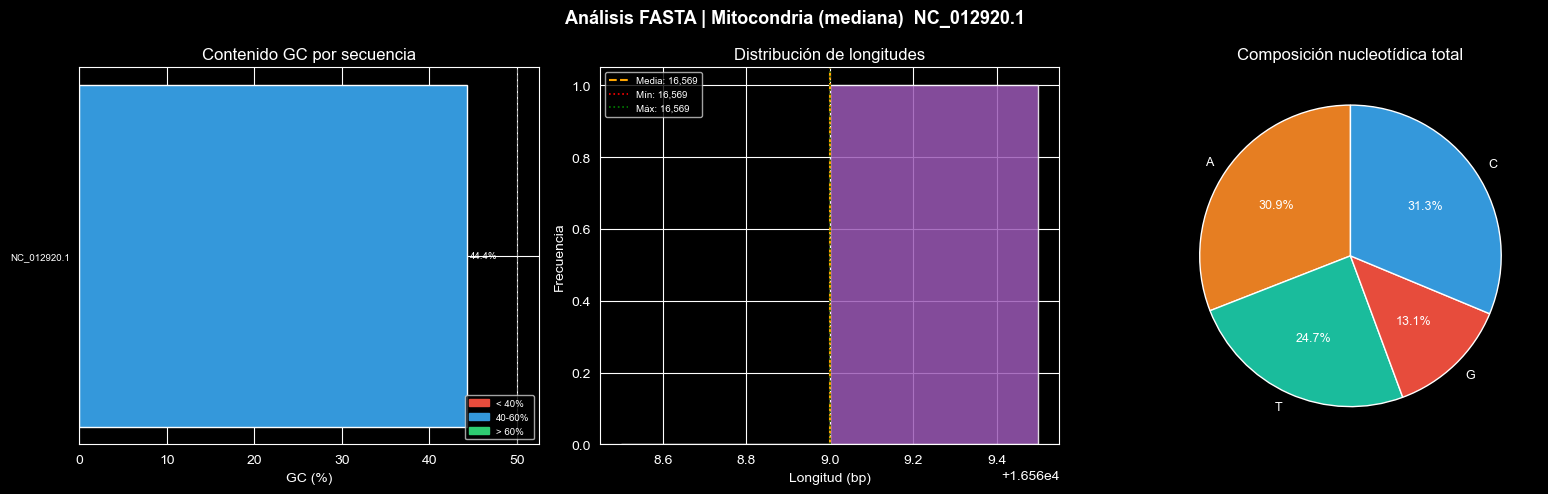

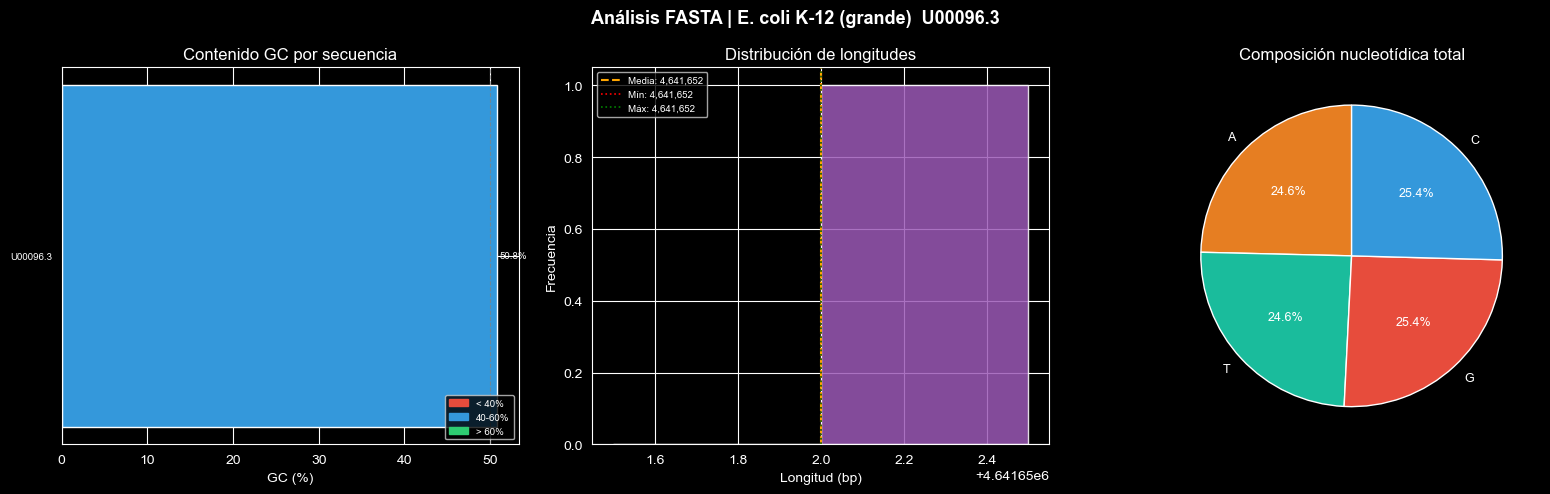

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualizar(records: list[FastaRecord], stats: StatsResult, label: str):
    ids      = [r.id for r in records]
    gc_vals  = [r.gc_content for r in records]
    lengths  = stats.lengths
    short_ids = [s[:16] + '..' if len(s) > 16 else s for s in ids]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Análisis FASTA | {label}", fontsize=13, fontweight='bold')

    # ── Panel 1: GC% por secuencia
    ax1 = axes[0]
    colors = ['#e74c3c' if g < 40 else '#2ecc71' if g > 60 else '#3498db'
              for g in gc_vals]
    bars = ax1.barh(range(len(ids)), gc_vals, color=colors, edgecolor='white')
    ax1.set_yticks(range(len(ids)))
    ax1.set_yticklabels(short_ids, fontsize=7)
    ax1.set_xlabel("GC (%)")
    ax1.set_title("Contenido GC por secuencia")
    ax1.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    for bar, val in zip(bars, gc_vals):
        ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va='center', fontsize=7)
    patches = [mpatches.Patch(color='#e74c3c', label='< 40%'),
               mpatches.Patch(color='#3498db', label='40-60%'),
               mpatches.Patch(color='#2ecc71', label='> 60%')]
    ax1.legend(handles=patches, fontsize=7, loc='lower right')

    # ── Panel 2: Histograma de longitudes
    ax2 = axes[1]
    ax2.hist(lengths, bins=min(30, len(lengths)+1),
             color='#9b59b6', edgecolor='white', alpha=0.85)
    ax2.axvline(stats.mean_len, color='orange', linewidth=1.5, linestyle='--',
                label=f"Media: {stats.mean_len:,.0f}")
    ax2.axvline(stats.min_len,  color='red',    linewidth=1.2, linestyle=':',
                label=f"Mín: {stats.min_len:,}")
    ax2.axvline(stats.max_len,  color='green',  linewidth=1.2, linestyle=':',
                label=f"Máx: {stats.max_len:,}")
    ax2.set_xlabel("Longitud (bp)")
    ax2.set_ylabel("Frecuencia")
    ax2.set_title("Distribución de longitudes")
    ax2.legend(fontsize=7)

    # ── Panel 3: Composición nucleotídica
    ax3 = axes[2]
    all_seq = ''.join(r.sequence for r in records)
    counts  = {b: all_seq.count(b) for b in 'ATGC'}
    total   = sum(counts.values())
    sizes   = [counts[b] / total * 100 for b in 'ATGC']
    ax3.pie(sizes, labels=list('ATGC'),
            colors=['#e67e22','#1abc9c','#e74c3c','#3498db'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
    ax3.set_title("Composición nucleotídica total")

    plt.tight_layout()
    plt.show()

# Generar gráfica para cada archivo analizado
for label, records, stats in resultados:
    visualizar(records, stats, label)


## 5. Comparativa de las tres secuencias


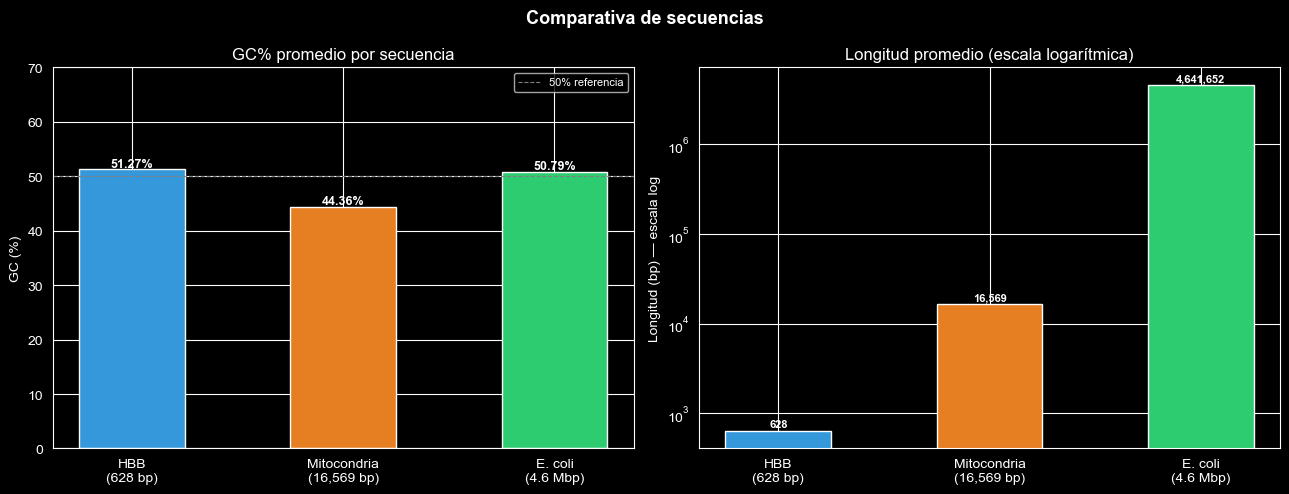

In [11]:
if resultados:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Comparativa de secuencias", fontsize=13, fontweight='bold')

    labels_short = ["HBB\n(628 bp)", "Mitocondria\n(16,569 bp)", "E. coli\n(4.6 Mbp)"]
    gc_medias    = [s.mean_gc  for _, _, s in resultados]
    longitudes   = [s.mean_len for _, _, s in resultados]
    colores      = ['#3498db', '#e67e22', '#2ecc71']

    # GC% comparativo
    ax1 = axes[0]
    bars = ax1.bar(labels_short[:len(gc_medias)], gc_medias,
                   color=colores[:len(gc_medias)], edgecolor='white', width=0.5)
    ax1.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% referencia')
    ax1.set_ylabel("GC (%)")
    ax1.set_title("GC% promedio por secuencia")
    ax1.set_ylim(0, 70)
    ax1.legend(fontsize=8)
    for bar, val in zip(bars, gc_medias):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.2f}%", ha='center', fontsize=9, fontweight='bold')

    # Longitudes comparativas (escala log)
    ax2 = axes[1]
    bars2 = ax2.bar(labels_short[:len(longitudes)], longitudes,
                    color=colores[:len(longitudes)], edgecolor='white', width=0.5)
    ax2.set_yscale('log')
    ax2.set_ylabel("Longitud (bp) — escala log")
    ax2.set_title("Longitud promedio (escala logarítmica)")
    for bar, val in zip(bars2, longitudes):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f"{val:,.0f}", ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()


## 6. Preguntas de Reflexión

1. **¿Por qué el genoma mitocondrial tiene un GC% menor (44.36%) que E. coli (50.79%)?**  
   _Responde aquí..._

2. **¿Qué pasaría si intentaras leer un archivo de 10 GB con `parse()`? ¿Qué usarías en su lugar?**  
   _Responde aquí..._

3. **Si una secuencia tiene GC% = 65%, ¿es más o menos estable térmicamente que una con GC% = 40%? ¿Por qué?**  
   _Responde aquí..._

4. **¿Cuál es la diferencia entre el ID y la descripción en un encabezado FASTA?**  
   _Responde aquí..._

---

## 7. Conclusiones

- El formato FASTA es texto plano que separa encabezado (`>`) de secuencia
- Implementamos tres clases con responsabilidades separadas: `FastaRecord` (modelo), `FastaReader` (I/O), `SequenceStats` (cómputo)
- El GC% varía según el organismo y la función biológica de la región
- Python permite procesar archivos de varios MB en milisegundos con lectura secuencial

---

## 8. Referencias

- NCBI Nucleotide: https://www.ncbi.nlm.nih.gov/nucleotide/
- Formato FASTA: https://www.ncbi.nlm.nih.gov/BLAST/fasta.shtml
- NM_000518.5 (HBB): https://www.ncbi.nlm.nih.gov/nuccore/NM_000518.5
- NC_012920.1 (Mitocondria): https://www.ncbi.nlm.nih.gov/nuccore/NC_012920.1
- U00096.3 (E. coli K-12): https://www.ncbi.nlm.nih.gov/nuccore/U00096.3
